In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cardio_train.csv", sep=";")


print(df.columns)



Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')


### EDA

Personer med hjärt- och kärlsjukdomar: 34979
Personer utan hjärt- och kärlsjukdomar: 35021
Personer med kolesterolnivåer runt normalen: 52385
Personer med kolesterolnivåer över det normala: 9549
Personer med kolesterolnivåer långt över det normala: 8066


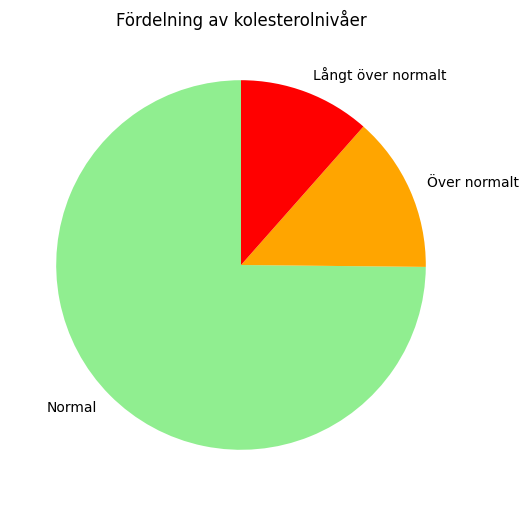

In [59]:
# EDA

# Sjuka vs friska
sick = df["cardio"].value_counts()[1]
healthy = df["cardio"].value_counts()[0]

print(f"Personer med hjärt- och kärlsjukdomar: {sick}")
print(f"Personer utan hjärt- och kärlsjukdomar: {healthy}")

# Kolesterol

normal_chol = df["cholesterol"].value_counts()[1]
raised_chol = df["cholesterol"].value_counts()[2]
high_chol = df["cholesterol"].value_counts()[3]
print(f"Personer med kolesterolnivåer runt normalen: {normal_chol}")
print(f"Personer med kolesterolnivåer över det normala: {raised_chol}")
print(f"Personer med kolesterolnivåer långt över det normala: {high_chol}")

chol_counts = df["cholesterol"].value_counts().sort_index()

labels = ["Normal", "Över normalt", "Långt över normalt"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(chol_counts, labels=labels, startangle=90, colors=["lightgreen", "orange", "red"])

ax.set_title("Fördelning av kolesterolnivåer")

plt.show()



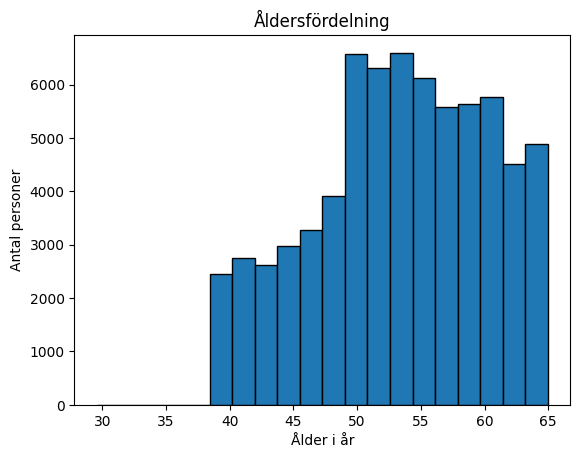

In [60]:
# Åldersfördelning

ages = df["age"].values
df["age_years"] = df["age"] / 365  

plt.hist(df["age_years"], bins=20, edgecolor='black')
plt.xlabel("Ålder i år")
plt.ylabel("Antal personer")
plt.title("Åldersfördelning")
plt.show()


In [61]:
# Hur många röker?

df_smokers = df[df["smoke"] == 1]
print(f"Antal rökare: {len(df_smokers)}")

Antal rökare: 6169


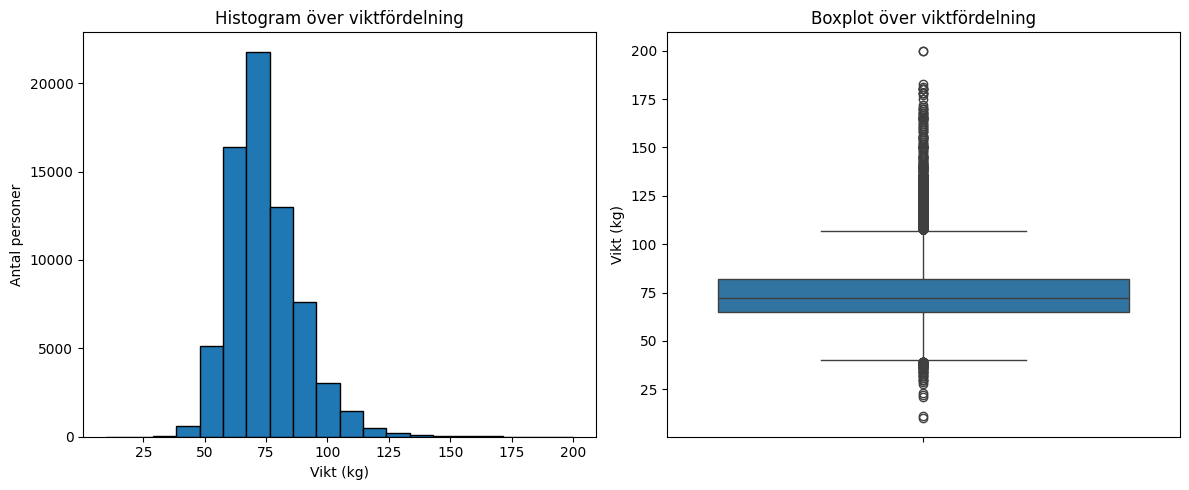

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))  


plt.subplot(1, 2, 1)  
plt.hist(df["weight"], bins=20, edgecolor='black')
plt.xlabel("Vikt (kg)")
plt.ylabel("Antal personer")
plt.title("Histogram över viktfördelning")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["weight"])
plt.ylabel("Vikt (kg)")
plt.title("Boxplot över viktfördelning")

plt.tight_layout()  
plt.show()


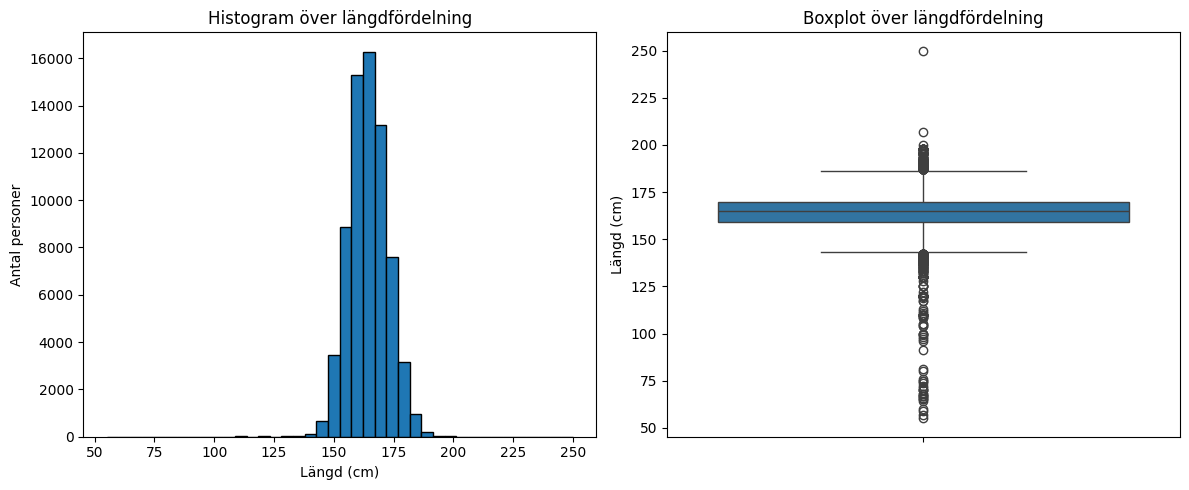

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))  


plt.subplot(1, 2, 1)  
plt.hist(df["height"], bins=40, edgecolor='black')
plt.xlabel("Längd (cm)")
plt.ylabel("Antal personer")
plt.title("Histogram över längdfördelning")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["height"])
plt.ylabel("Längd (cm)")
plt.title("Boxplot över längdfördelning")

plt.tight_layout()  
plt.show()


Antal män med hjärt- och kärlsjukdomar: 12363
Antal kvinnor med hjärt- och kärlsjukdomar: 22616


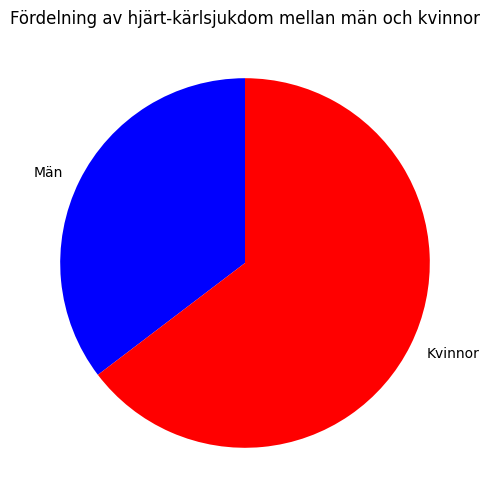

In [64]:
df_men = df[(df["cardio"] == 1) & (df["gender"] == 2)]
df_women = df[(df["cardio"] == 1) & (df["gender"] == 1)]
print(f"Antal män med hjärt- och kärlsjukdomar: {len(df_men)}")
print(f"Antal kvinnor med hjärt- och kärlsjukdomar: {len(df_women)}")


labels = ["Män", "Kvinnor"]
gender_split = [len(df_men), len(df_women)]
colors = ["blue", "red"] 


plt.figure(figsize=(6, 6))
plt.pie(gender_split, labels=labels, startangle=90, colors=colors)  
plt.title("Fördelning av hjärt-kärlsjukdom mellan män och kvinnor")


plt.show()


### Feature Engineering BMI


In [65]:
# BMI = vikt / (längd^2)

df["height_meters"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_meters"] ** 2)

df.drop(columns=["height_meters"], inplace=True)

# Jag valde att ta bort BMI-värden som var under 10 (vilket bör vara felaktig data pga hur lågt det är) och över 60 (vilket också bör vara felaktig data pga hur högt det är)
df = df[(df["BMI"] >= 10) & (df["BMI"] <= 60)]

# BMI-fördelningen görs enligt följande katergorier:
# Normalvikt: 18.5 - 24.9
# Övervikt: 25 - 29.9
# Fetma klass 1: 30 - 34.9
# Fetma klass 2: 35 - 39.9
# Fetma klass 3: > 40

# Jag valde här att lägga in "float(inf)" för att hantera BMI-värden över 40
BMI_ranges = [18.5, 24.9, 29.9, 34.9, 39.9, float('inf')]
labels = ["Normal weight", "Overweight", "Obese Class I", "Obese Class II", "Obese Class III"]

# Med pd.cut så kan jag "klippa in" en kolumn i en DataFrame och dela upp den i kategorier enligt de intervall jag angett ovan
df["BMI_category"] = pd.cut(df["BMI"], bins=BMI_ranges, labels=labels)


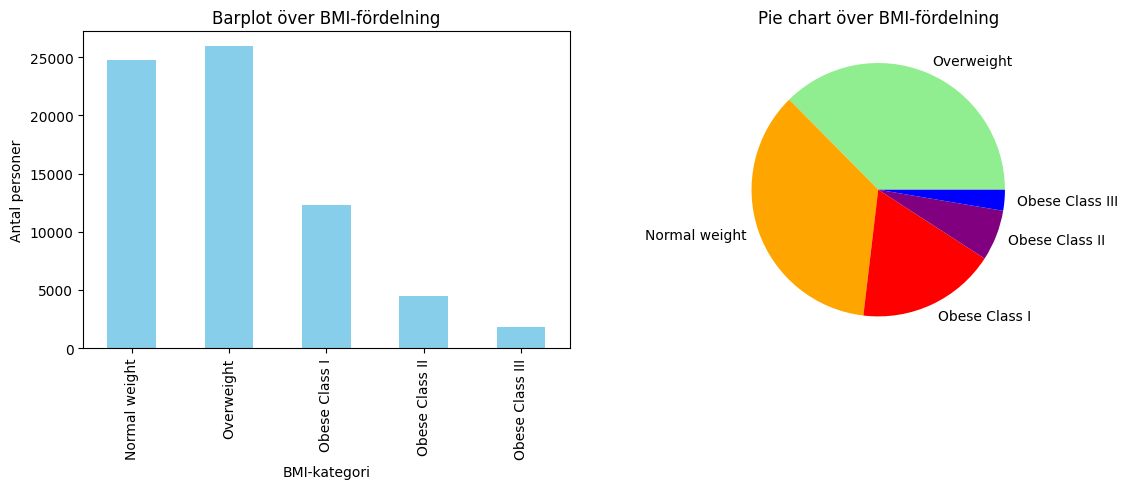

In [66]:


plt.figure(figsize=(12, 5)) 


plt.subplot(1, 2, 1)  
df["BMI_category"].value_counts().sort_index().plot(kind="bar", color="skyblue")
plt.xlabel("BMI-kategori")
plt.ylabel("Antal personer")
plt.title("Barplot över BMI-fördelning")


plt.subplot(1, 2, 2)
df["BMI_category"].value_counts().plot(kind="pie", colors=["lightgreen", "orange", "red", "purple", "blue", "pink"])
plt.ylabel("") 
plt.title("Pie chart över BMI-fördelning")

plt.tight_layout() 
plt.show()


In [67]:
# ap_hi = systoliskt blodtryck
# ap_lo = diastoliskt blodtryck

# orealistiska värden för ap_hi är: < 60 och > 300
# orealistiska värden för ap_lo är: < 30 och > 200 
# Jag kom fram till dessa värden genom att läsa på om blodtrycksvärden via dessa länkar:
#   * https://www.healthline.com/health/high-blood-pressure-hypertension#symptoms
#   * https://www.nhlbi.nih.gov/health/low-blood-pressure
df = df[(df["ap_hi"] >= 60) & (df["ap_hi"] <= 300)]
df = df[(df["ap_lo"] >= 30) & (df["ap_lo"] <= 200)]

# healthy, elevated, stage 1 hypertension, stage 2 hypertension, hypertensive crisis

def categorize_blood_pressure(ap_hi, ap_lo):
    if ap_hi > 180 or ap_lo > 120:
        return "Hypertensive Crisis"
    elif ap_hi >= 140 or ap_lo >= 90:
        return "Stage 2 Hypertension"
    elif ap_hi >= 130 or ap_lo >= 80:
        return "Stage 1 Hypertension"
    elif ap_hi >= 120 and ap_lo < 80:
        return "Elevated"
    else:
        return "Healthy"

    
# ap_hi_ranges = [120, 129, 139, 179, float('inf')]
# ap_lo_ranges = [80, 80, 89, 119, float('inf')]

# egen anteckning: df.apply är till för att applicera en funktion på varje rad i en DataFrame
df["BP_category"] = df.apply(lambda row: categorize_blood_pressure(row["ap_hi"], row["ap_lo"]), axis=1)

# Här kollar jag på 10 rader ifrån df för att manuellt se om BP_category har satts korrekt
df.sample(10)[["ap_hi", "ap_lo", "BP_category"]]


,ap_hi,ap_lo,BP_category
7269,110,70,Healthy
26637,110,70,Healthy
69344,120,80,Stage 1 Hypertension
38778,120,80,Stage 1 Hypertension
19337,120,80,Stage 1 Hypertension
14974,90,70,Healthy
68724,160,90,Stage 2 Hypertension
33074,130,90,Stage 2 Hypertension
14232,130,80,Stage 1 Hypertension
26443,140,65,Stage 2 Hypertension


/tmp/ipykernel_14274/2107488794.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cardio_BMI = df.groupby("BMI_category")["cardio"].mean()
/tmp/ipykernel_14274/2107488794.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cardio_age_group = df.groupby(pd.cut(df["age_years"], bins=range(30, 71, 5), right=False))["cardio"].mean()


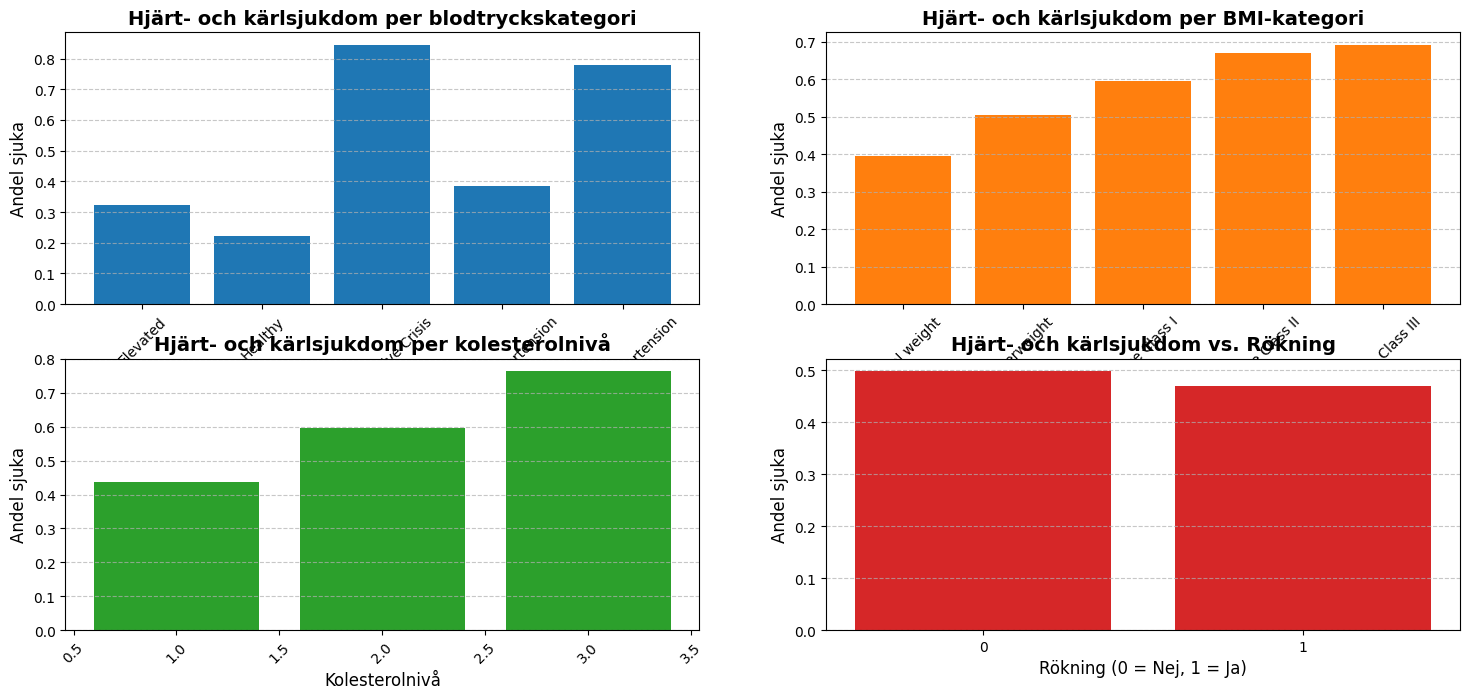

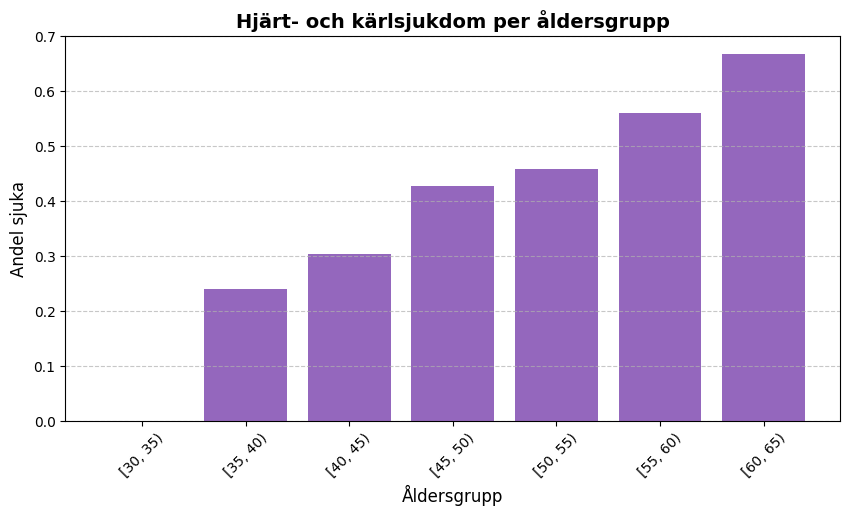

In [68]:
df_cardio_bp = df.groupby("BP_category")["cardio"].mean()
df_cardio_BMI = df.groupby("BMI_category")["cardio"].mean()
df_cardio_chol = df.groupby("cholesterol")["cardio"].mean()
df_cardio_smoke = df.groupby("smoke")["cardio"].mean()
df_cardio_age = df.groupby("age_years")["cardio"].mean()


df_cardio_smoke.index = df_cardio_smoke.index.astype(str)


plt.figure(figsize=(18, 12))


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# Subplot 1: Blodtryckskategorier
plt.subplot(3, 2, 1)  
plt.bar(df_cardio_bp.index, df_cardio_bp, color=colors[0])
plt.xlabel("Blodtryckskategori", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per blodtryckskategori", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 2: BMI-kategorier
plt.subplot(3, 2, 2)  
plt.bar(df_cardio_BMI.index, df_cardio_BMI, color=colors[1])
plt.xlabel("BMI-kategori", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per BMI-kategori", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 3: Kolesterolnivåer
plt.subplot(3, 2, 3)  
plt.bar(df_cardio_chol.index, df_cardio_chol, color=colors[2])
plt.xlabel("Kolesterolnivå", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per kolesterolnivå", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 4: Rökning
plt.subplot(3, 2, 4)  
plt.bar(df_cardio_smoke.index, df_cardio_smoke, color=colors[3])
plt.xlabel("Rökning (0 = Nej, 1 = Ja)", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom vs. Rökning", fontsize=14, fontweight="bold")
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)


df_cardio_age_group = df.groupby(pd.cut(df["age_years"], bins=range(30, 71, 5), right=False))["cardio"].mean()


plt.figure(figsize=(10, 5))
plt.bar(df_cardio_age_group.index.astype(str), df_cardio_age_group, color="#9467bd")
plt.xlabel("Åldersgrupp", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per åldersgrupp", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10) 
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [69]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)


                   id       age    gender    height    weight     ap_hi  \
id           1.000000  0.003501  0.003107 -0.003438 -0.001775  0.001303   
age          0.003501  1.000000 -0.023131 -0.084572  0.055224  0.208708   
gender       0.003107 -0.023131  1.000000  0.514169  0.157904  0.061439   
height      -0.003438 -0.084572  0.514169  1.000000  0.310484  0.019322   
weight      -0.001775  0.055224  0.157904  0.310484  1.000000  0.269377   
ap_hi        0.001303  0.208708  0.061439  0.019322  0.269377  1.000000   
ap_lo       -0.000608  0.152626  0.066544  0.036796  0.249302  0.696851   
cholesterol  0.005892  0.155515 -0.036624 -0.053863  0.142351  0.193952   
gluc         0.002272  0.099149 -0.021055 -0.020564  0.107722  0.092575   
smoke       -0.003332 -0.047841  0.338760  0.194170  0.067374  0.027159   
alco         0.000669 -0.029014  0.170952  0.097807  0.068528  0.032517   
active       0.003753 -0.010512  0.005929 -0.008454 -0.018393 -0.001336   
cardio       0.003779  0.

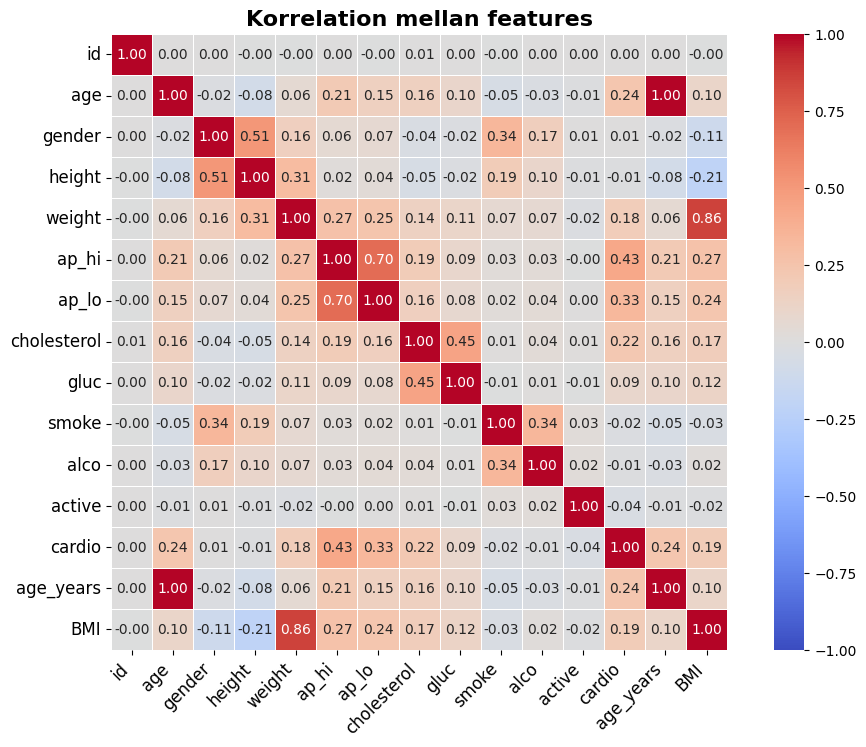

In [70]:

plt.figure(figsize=(12, 8))


sns.heatmap(
    correlation_matrix, 
    annot=True,         # Visa korrelationsvärden
    cmap="coolwarm",    # Färgskala
    fmt=".2f",          # Två decimaler
    linewidths=0.5,     # Små linjer mellan rutor
    square=True,        # Gör varje cell kvadratisk
    vmin=-1, vmax=1     # Sätter skalan från -1 till 1
)


plt.xticks(rotation=45, ha="right", fontsize=12)  
plt.yticks(fontsize=12) 
plt.title("Korrelation mellan features", fontsize=16, fontweight="bold")

plt.show()


Korrelationerna i heatmappen visar flera intressanta samband mellan faktorer och hjärt- och kärlsjukdomar (cardio):

Blodtryck (ap_hi och ap_lo) har stark koppling till hjärt- och kärlsjukdomar – Högt blodtryck är en av de största riskfaktorerna för hjärtsjukdom, vilket syns i den positiva korrelationen mellan ap_hi, ap_lo och cardio.

Ålder, kolesterol och BMI påverkar hjärt- och kärlsjukdomar – Äldre personer tenderar att ha högre risk för hjärtsjukdom, och högt kolesterol samt fetma är välkända riskfaktorer, vilket förklarar deras positiva korrelationer med cardio.

Stark korrelation mellan ap_hi och ap_lo (0.7) – Detta är logiskt eftersom systoliskt och diastoliskt blodtryck ofta höjs och sänks tillsammans.

Glukos (gluc) och kolesterol (cholesterol) har en koppling – En möjlig förklaring är att båda kan höjas av ohälsosam kost och metabola syndrom, vilket ökar risken för diabetes och hjärtsjukdomar.

Överraskande låg korrelation mellan fysisk aktivitet (active) och hjärtsjukdomar – Man skulle kunna tro att fysisk aktivitet har en skyddande effekt, men den låga korrelationen kan bero på att andra faktorer (som kost och genetik) har större påverkan i detta dataset.

In [71]:
df1 = df.drop(columns=["ap_hi", "ap_lo", "height", "weight", "BMI"])
df2 = df.drop(columns=["BMI_category", "BP_category", "height", "weight"])

df1 = pd.get_dummies(df1, columns=["BMI_category", "BP_category", "gender"], drop_first=True)
df2 = pd.get_dummies(df2, columns=["gender"], drop_first=True)


In [72]:
from sklearn.model_selection import train_test_split


X_train1, X_test1, y_train1, y_test1 = train_test_split(df1.drop(columns=["cardio"]), df1["cardio"], test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(df2.drop(columns=["cardio"]), df2["cardio"], test_size=0.2, random_state=42)


X_val1, X_test1, y_val1, y_test1 = train_test_split(X_test1, y_test1, test_size=0.5, random_state=42)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_test2, y_test2, test_size=0.5, random_state=42)


In [73]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler används här för modellerna: Logistic Regression, SVM, KNN och Naive Bayes
std_scaler = StandardScaler()

X_train1_scaled = std_scaler.fit_transform(X_train1)
X_val1_scaled = std_scaler.transform(X_val1)
X_test1_scaled = std_scaler.transform(X_test1)

X_train2_scaled = std_scaler.fit_transform(X_train2)
X_val2_scaled = std_scaler.transform(X_val2)
X_test2_scaled = std_scaler.transform(X_test2)


In [74]:
# MinMaxScaler används för modellen Random Forest
minmax_scaler = MinMaxScaler()


X_train1_norm = minmax_scaler.fit_transform(X_train1)
X_val1_norm = minmax_scaler.transform(X_val1)
X_test1_norm = minmax_scaler.transform(X_test1)


X_train2_norm = minmax_scaler.fit_transform(X_train2)
X_val2_norm = minmax_scaler.transform(X_val2)
X_test2_norm = minmax_scaler.transform(X_test2)


In [75]:
# Param grids

param_grid_logreg = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],  
    "solver": ["liblinear", "lbfgs"] 
}

param_grid_svm = {
    "C": [0.1, 1, 10, 100],  
    "kernel": ["linear", "rbf", "poly"],  
    "gamma": ["scale", "auto"]  
}

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],  
    "weights": ["uniform", "distance"], 
    "metric": ["euclidean", "manhattan"]
}

param_grid_rf = {
    "n_estimators": [50, 100, 200], 
    "max_depth": [None, 10, 20, 30], 
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4] 
}


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

logreg_model = LogisticRegression(max_iter=1000)
svm_model = SVC()
knn_model = KNeighborsClassifier()
rf_model = RandomForestClassifier()




In [77]:
def run_grid_search(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    print(f"Bästa parametrar för {model.__class__.__name__}: {grid_search.best_params_}")
    print(f"Bästa validerings-accuracy: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_



In [78]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), param_grid_logreg),
    "SVM": (SVC(), param_grid_svm),
    "KNN": (KNeighborsClassifier(), param_grid_knn),
    "Random Forest": (RandomForestClassifier(), param_grid_rf)
}

best_models = {}

for name, (model, param_grid) in models.items():
    print(f"\n🔍 Tränar {name} på dataset 1...")
    best_models[f"{name}_df1"] = run_grid_search(model, param_grid, X_train1_scaled, y_train1)
    
    print(f"\n🔍 Tränar {name} på dataset 2...")
    best_models[f"{name}_df2"] = run_grid_search(model, param_grid, X_train2_scaled, y_train2)


🔍 Tränar Logistic Regression på dataset 1...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa parametrar för LogisticRegression: {'C': 0.01, 'solver': 'lbfgs'}
Bästa validerings-accuracy: 0.7221

🔍 Tränar Logistic Regression på dataset 2...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bästa parametrar för LogisticRegression: {'C': 10, 'solver': 'lbfgs'}
Bästa validerings-accuracy: 0.7277

🔍 Tränar SVM på dataset 1...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 